## Assignment 1: Data Analysis and Machine Learning

### Ky Cuong Pham a1906313

#### How can we use data analytics and Machine Learning to predict energy usage for this house?

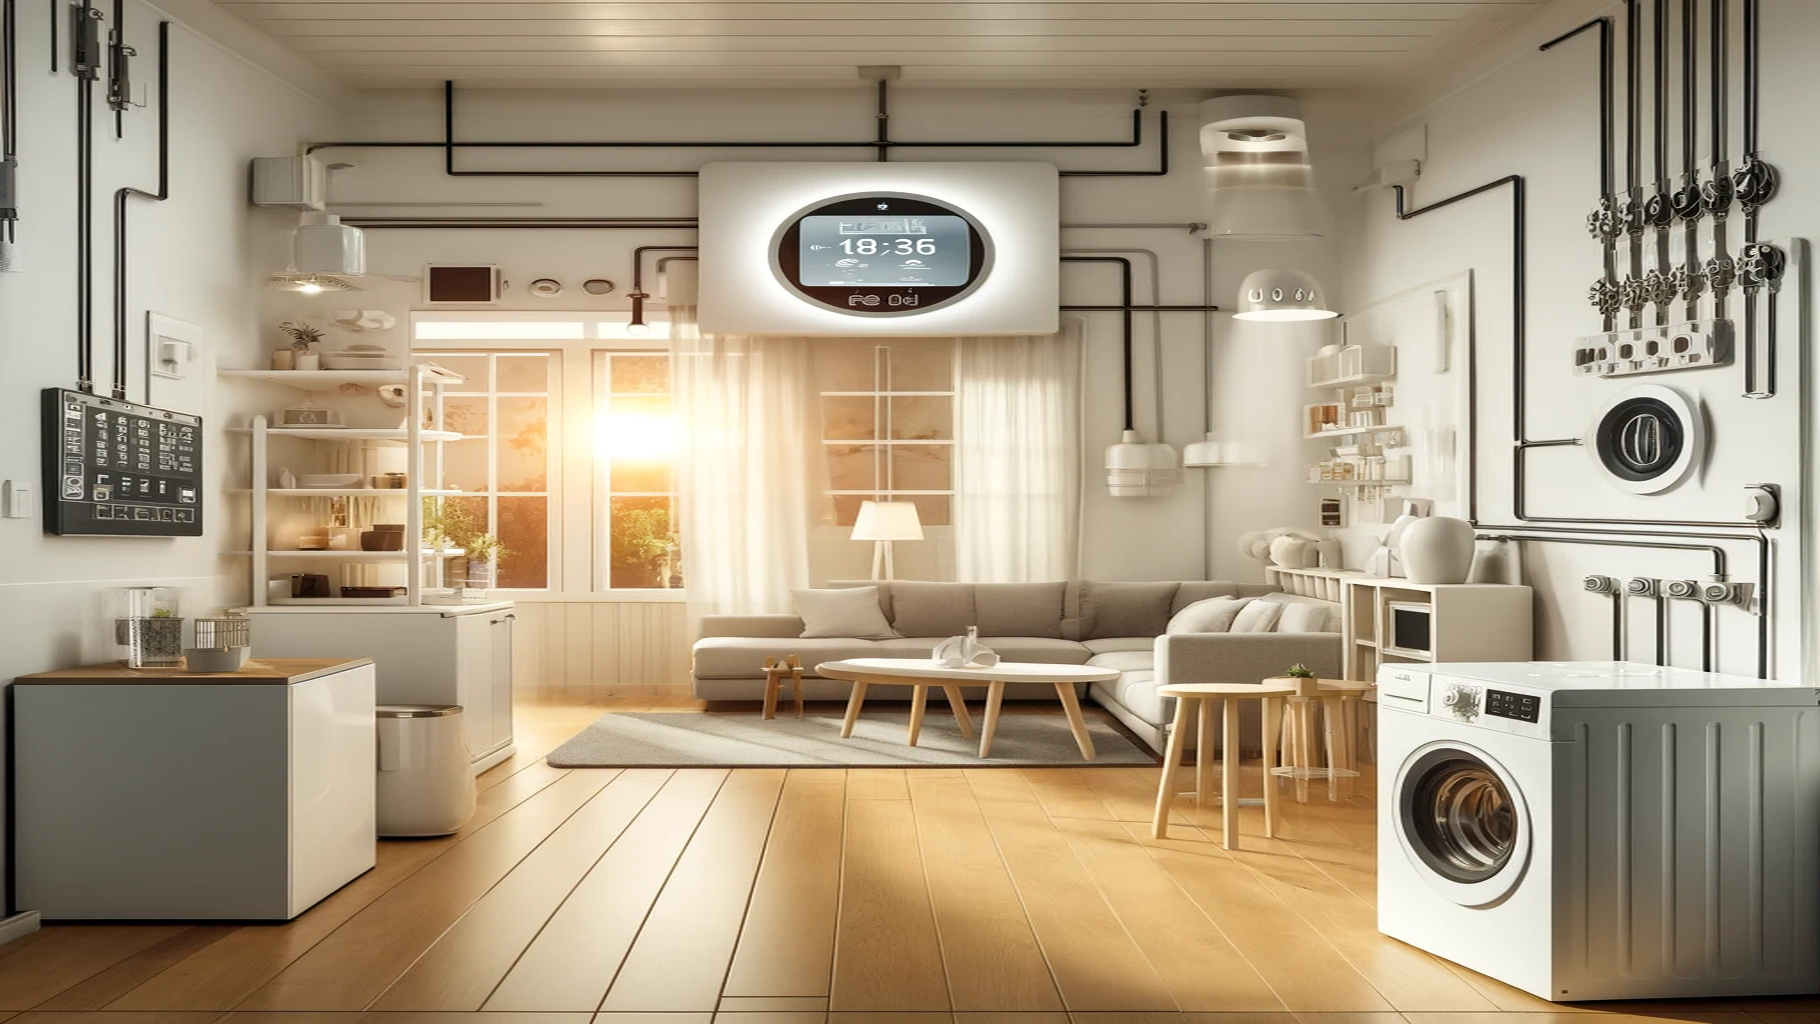

#### Follow detail instructions in the assignment specification and use these heading for implementation and discussion

In [2]:
# chatGPT. Prompt: "reorganize the imports"

# seed the random numbers for reproducibility 
# do not remove this line
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import random
random.seed(10)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

### 1. Analyse and visualise the data

#### 1.1. Read the dataset

In [3]:
orginal_df = pd.read_csv('energydata_complete.csv')
print(orginal_df.shape)
orginal_df.head()

(14941, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,14/02/2016 0:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,...,18.0,41.933333,2.90,732.90,98.000000,2.000000,31.0,2.6,48.320978,48.320978
1,14/02/2016 0:10,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,...,18.0,42.133333,2.87,732.95,98.166667,2.166667,28.5,2.6,33.339359,33.339359
2,14/02/2016 0:20,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,...,18.0,42.360000,2.83,733.00,98.333333,2.333333,26.0,2.6,8.168115,8.168115
3,14/02/2016 0:30,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,...,18.0,42.633333,2.80,733.05,98.500000,2.500000,23.5,2.6,16.197509,16.197509
4,14/02/2016 0:40,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,...,18.0,42.860000,2.77,733.10,98.666667,2.666667,21.0,2.6,12.559574,12.559574


In [4]:
#Keep the original data isolated
df = orginal_df.copy()
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)
df.head()

# introduce new features Number of seconds from midnight
df['NSM'] = df.index.hour*3600 + df.index.minute*60 + df.index.second

In [5]:
# date time year-month-day hour:minute:second 
# Appliances, energy use in Wh
# lights, energy use of light fixtures in the house in Wh
# T1, Temperature in kitchen area, in Celsius
# RH_1, Humidity in kitchen area, in %
# T2, Temperature in living room area, in Celsius
# RH_2, Humidity in living room area, in %
# T3, Temperature in laundry room area
# RH_3, Humidity in laundry room area, in %
# T4, Temperature in office room, in Celsius
# RH_4, Humidity in office room, in %
# T5, Temperature in bathroom, in Celsius
# RH_5, Humidity in bathroom, in %
# T6, Temperature outside the building (north side), in Celsius
# RH_6, Humidity outside the building (north side), in %
# T7, Temperature in ironing room , in Celsius
# RH_7, Humidity in ironing room, in %
# T8, Temperature in teenager room 2, in Celsius
# RH_8, Humidity in teenager room 2, in %
# T9, Temperature in parents room, in Celsius
# RH_9, Humidity in parents room, in %
# To_out, Temperature outside (from Chievres weather station), in Celsius
# Press_mg_hg, Pressure (from Chievres weather station), in mm Hg
# RH_out, Humidity outside (from Chievres weather station), in %
# Wind speed (from Chievres weather station), in m/s
# Visibility (from Chievres weather station), in km
# Tdewpoint (from Chievres weather station), Â°C
# rv1, Random variable 1, nondimensional
# rv2, Random variable 2, nondimensional

# !!!rv1 and rv2 are just for testing the robustness of the model, it should not rely on these variables
# the model should be able to predict the energy use without these variables
print(f"Shape of the df: {df.shape}")
print(f"Columns in the df: {df.columns}")

Shape of the df: (14941, 29)
Columns in the df: Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2', 'NSM'],
      dtype='object')


#### 1.2. Analyse data characteristics

In this section I have done:
- Checking for basic information using pandas functions such as describe(), info()
- Checking for duplication and missing values

- Plot graphs
Here are some general insights: 
1. Data size: contains 14941 data points
2. Data type: most of the columns are numeric, except for the "date" as object
3. Data missing: there are no missing data -> high quality dataset
4. Scaling: our Appliances columns can be substituted with log_appliances
5. Relationship: while the appliances might have some relationship with temperatures, humidity, some others climate features and strongly with what time is it(hour); some of the features are not that useful

In [6]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,NSM
count,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,...,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000,14941.000000
mean,96.747206,3.235393,22.030776,39.418672,20.519140,39.935868,22.770465,38.046386,21.425985,37.701517,...,40.454742,8.182569,755.575393,77.559434,3.671039,37.922696,4.055227,25.047636,25.047636,42823.398702
std,97.297111,7.296554,1.469766,3.880367,2.322643,4.328421,1.897689,2.530175,1.843571,3.701348,...,3.566295,5.464633,6.613943,15.720014,2.218070,11.415145,4.220123,14.436670,14.436670,24918.908349
min,10.000000,0.000000,18.600000,27.023333,16.200000,20.463333,19.100000,28.766667,17.290000,27.660000,...,29.166667,-4.400000,732.900000,24.000000,0.000000,1.000000,-6.100000,0.005322,0.005322,0.000000
25%,50.000000,0.000000,21.000000,36.790000,18.890000,37.260000,21.390000,36.363333,20.100000,34.900000,...,38.030000,4.230000,751.200000,66.666667,2.000000,29.000000,0.983000,12.593007,12.593007,21000.000000
50%,60.000000,0.000000,21.823333,38.790000,20.000000,39.900000,22.566667,37.760000,21.166667,37.200000,...,39.863333,7.630000,755.700000,80.833333,3.166667,40.000000,3.600000,25.120708,25.120708,42600.000000
75%,100.000000,0.000000,22.890000,41.400000,21.830000,42.700000,24.033333,39.260000,22.738571,39.700000,...,42.530000,11.400000,760.200000,90.833333,5.000000,40.000000,6.900000,37.454428,37.454428,64200.000000
max,900.000000,50.000000,26.260000,57.496667,29.856667,56.026667,29.236000,47.693333,26.200000,50.760000,...,51.536000,26.100000,772.300000,100.000000,13.000000,66.000000,15.500000,49.992758,49.992758,85800.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14941 entries, 2016-02-14 00:00:00 to 2016-05-27 18:00:00
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   14941 non-null  int64  
 1   lights       14941 non-null  int64  
 2   T1           14941 non-null  float64
 3   RH_1         14941 non-null  float64
 4   T2           14941 non-null  float64
 5   RH_2         14941 non-null  float64
 6   T3           14941 non-null  float64
 7   RH_3         14941 non-null  float64
 8   T4           14941 non-null  float64
 9   RH_4         14941 non-null  float64
 10  T5           14941 non-null  float64
 11  RH_5         14941 non-null  float64
 12  T6           14941 non-null  float64
 13  RH_6         14941 non-null  float64
 14  T7           14941 non-null  float64
 15  RH_7         14941 non-null  float64
 16  T8           14941 non-null  float64
 17  RH_8         14941 non-null  float64
 18  T9         

In [8]:
df.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
NSM            0
dtype: int64

In [9]:
df.duplicated().sum()

0

First, I checked for data completeness. No missing data or duplication -> this dataset is high quality.

<Figure size 1200x600 with 0 Axes>

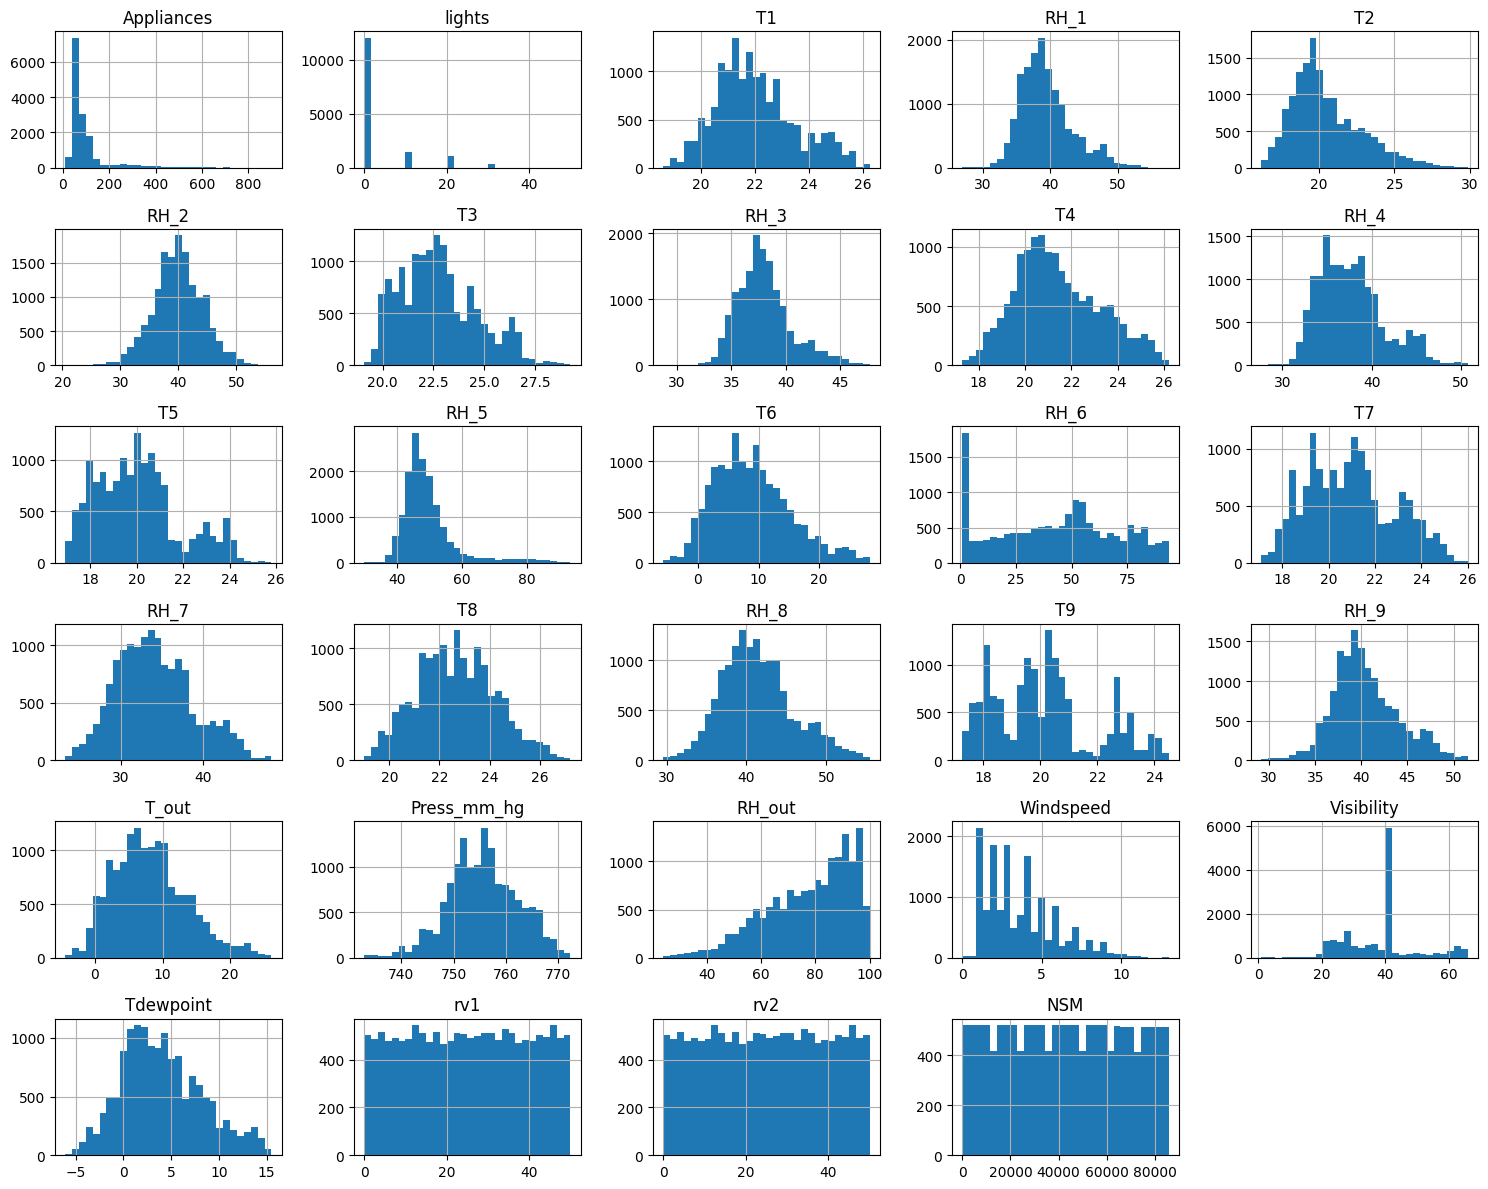

In [10]:
# chatGPT. Prompt: "plot the histogram"

plt.figure(figsize=(12, 6))
df.hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

I then chose to plot all of the histogram to have a general idea about each feature's distribution, because by looking at the ***Appliances*** plot, we can see the data is not normally distributed. So that I applied log() to create ***log_appliances*** feature.

Text(0.5, 0, 'Appliances log(wH)')

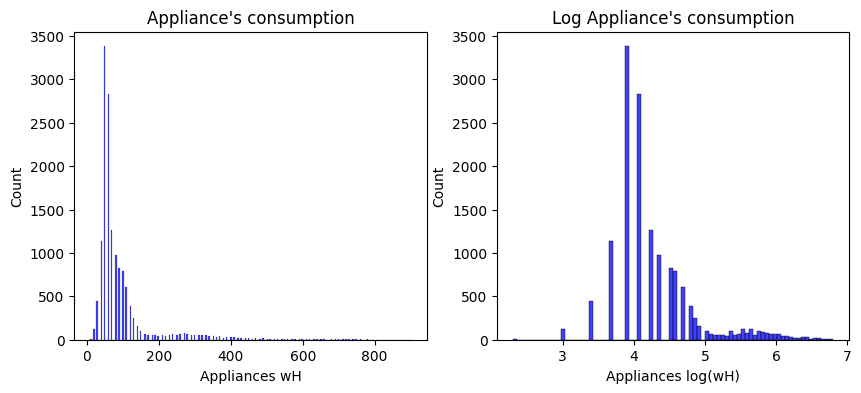

In [11]:
f, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['Appliances'], element='bars', color='blue', edgecolor='black', ax=axes[0])
axes[0].set_title("Appliance's consumption")
axes[0].set_xlabel('Appliances wH')

df['log_appliances'] = np.log(df['Appliances'])
sns.histplot(df['log_appliances'], element='bars', color='blue', edgecolor='black', ax=axes[1])
axes[1].set_title("Log Appliance's consumption")
axes[1].set_xlabel('Appliances log(wH)')

***log_appliances*** is closer to normal distribution, migitating unstable learning when the target is skewed. From now, we will substitute ***Appliances*** with its log

After multiple iterations of EDA with different time windows, I found ***hour***, which is extracted from ***date***, is highly correlated with our target.

In [12]:
df['hour'] = df.index.hour
df['hour_avg'] = df.groupby('hour')['Appliances'].transform('mean')
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,NSM,log_appliances,hour,hour_avg
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,...,98.000000,2.000000,31.0,2.6,48.320978,48.320978,0,3.912023,0,52.5
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,...,98.166667,2.166667,28.5,2.6,33.339359,33.339359,600,3.912023,0,52.5
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,...,98.333333,2.333333,26.0,2.6,8.168115,8.168115,1200,4.094345,0,52.5
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,...,98.500000,2.500000,23.5,2.6,16.197509,16.197509,1800,3.688879,0,52.5
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,...,98.666667,2.666667,21.0,2.6,12.559574,12.559574,2400,4.094345,0,52.5


Text(0, 0.5, 'Energy Usage (Wh)')

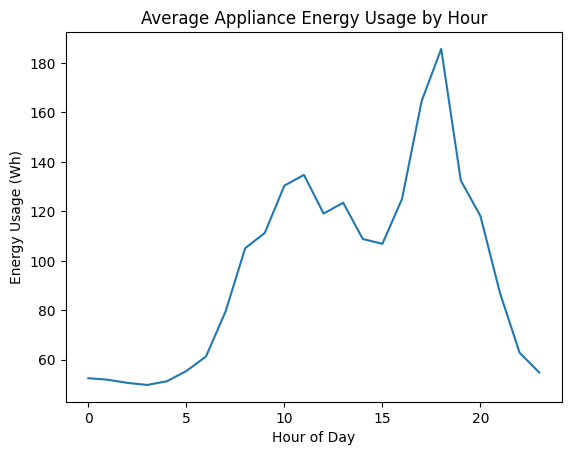

In [13]:
daily_energy = df.groupby('hour')['Appliances'].mean()
sns.lineplot(x=daily_energy.index, y=daily_energy.values)
plt.title('Average Appliance Energy Usage by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Energy Usage (Wh)')

The shown pattern is obvious and understandable. Energy usage peaks at 10 a.m and 6 p.m, and drops for the in-between period of time. This can be attributed to the fact that people might get ready for the day, get out and come back home after work.

Text(0.5, 1.0, 'Average Indoor Temperature vs Energy Usage')

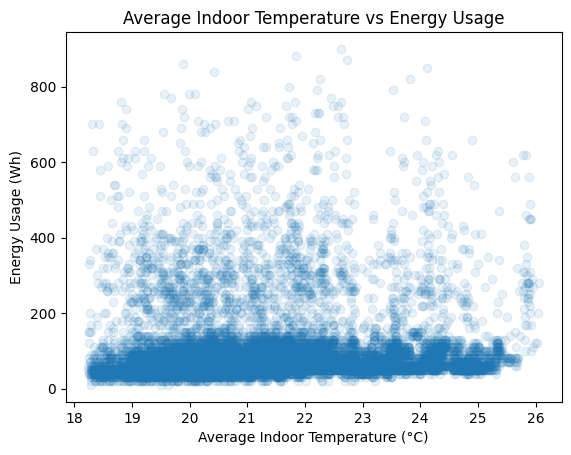

In [14]:
# avarage inside temp impact on energy usage
avg_indoor_temps = df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
plt.scatter(avg_indoor_temps, df['Appliances'], alpha=0.1)
plt.xlabel('Average Indoor Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Average Indoor Temperature vs Energy Usage')

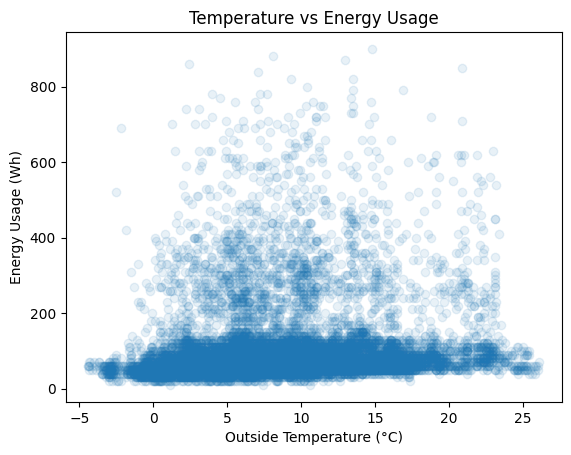

In [15]:

# Outside temp impact on energy usage
plt.scatter(df['T_out'], df['Appliances'], alpha=0.1)
plt.xlabel('Outside Temperature (°C)')
plt.ylabel('Energy Usage (Wh)')
plt.title('Temperature vs Energy Usage')
plt.show()

At first, I thought temperature might contribute to the amount of energy used because of the need of using more A/C or heater. However, the plots do not show any strong relationship. The wide disperse of those points is showing that there is a non-linearity between those features.

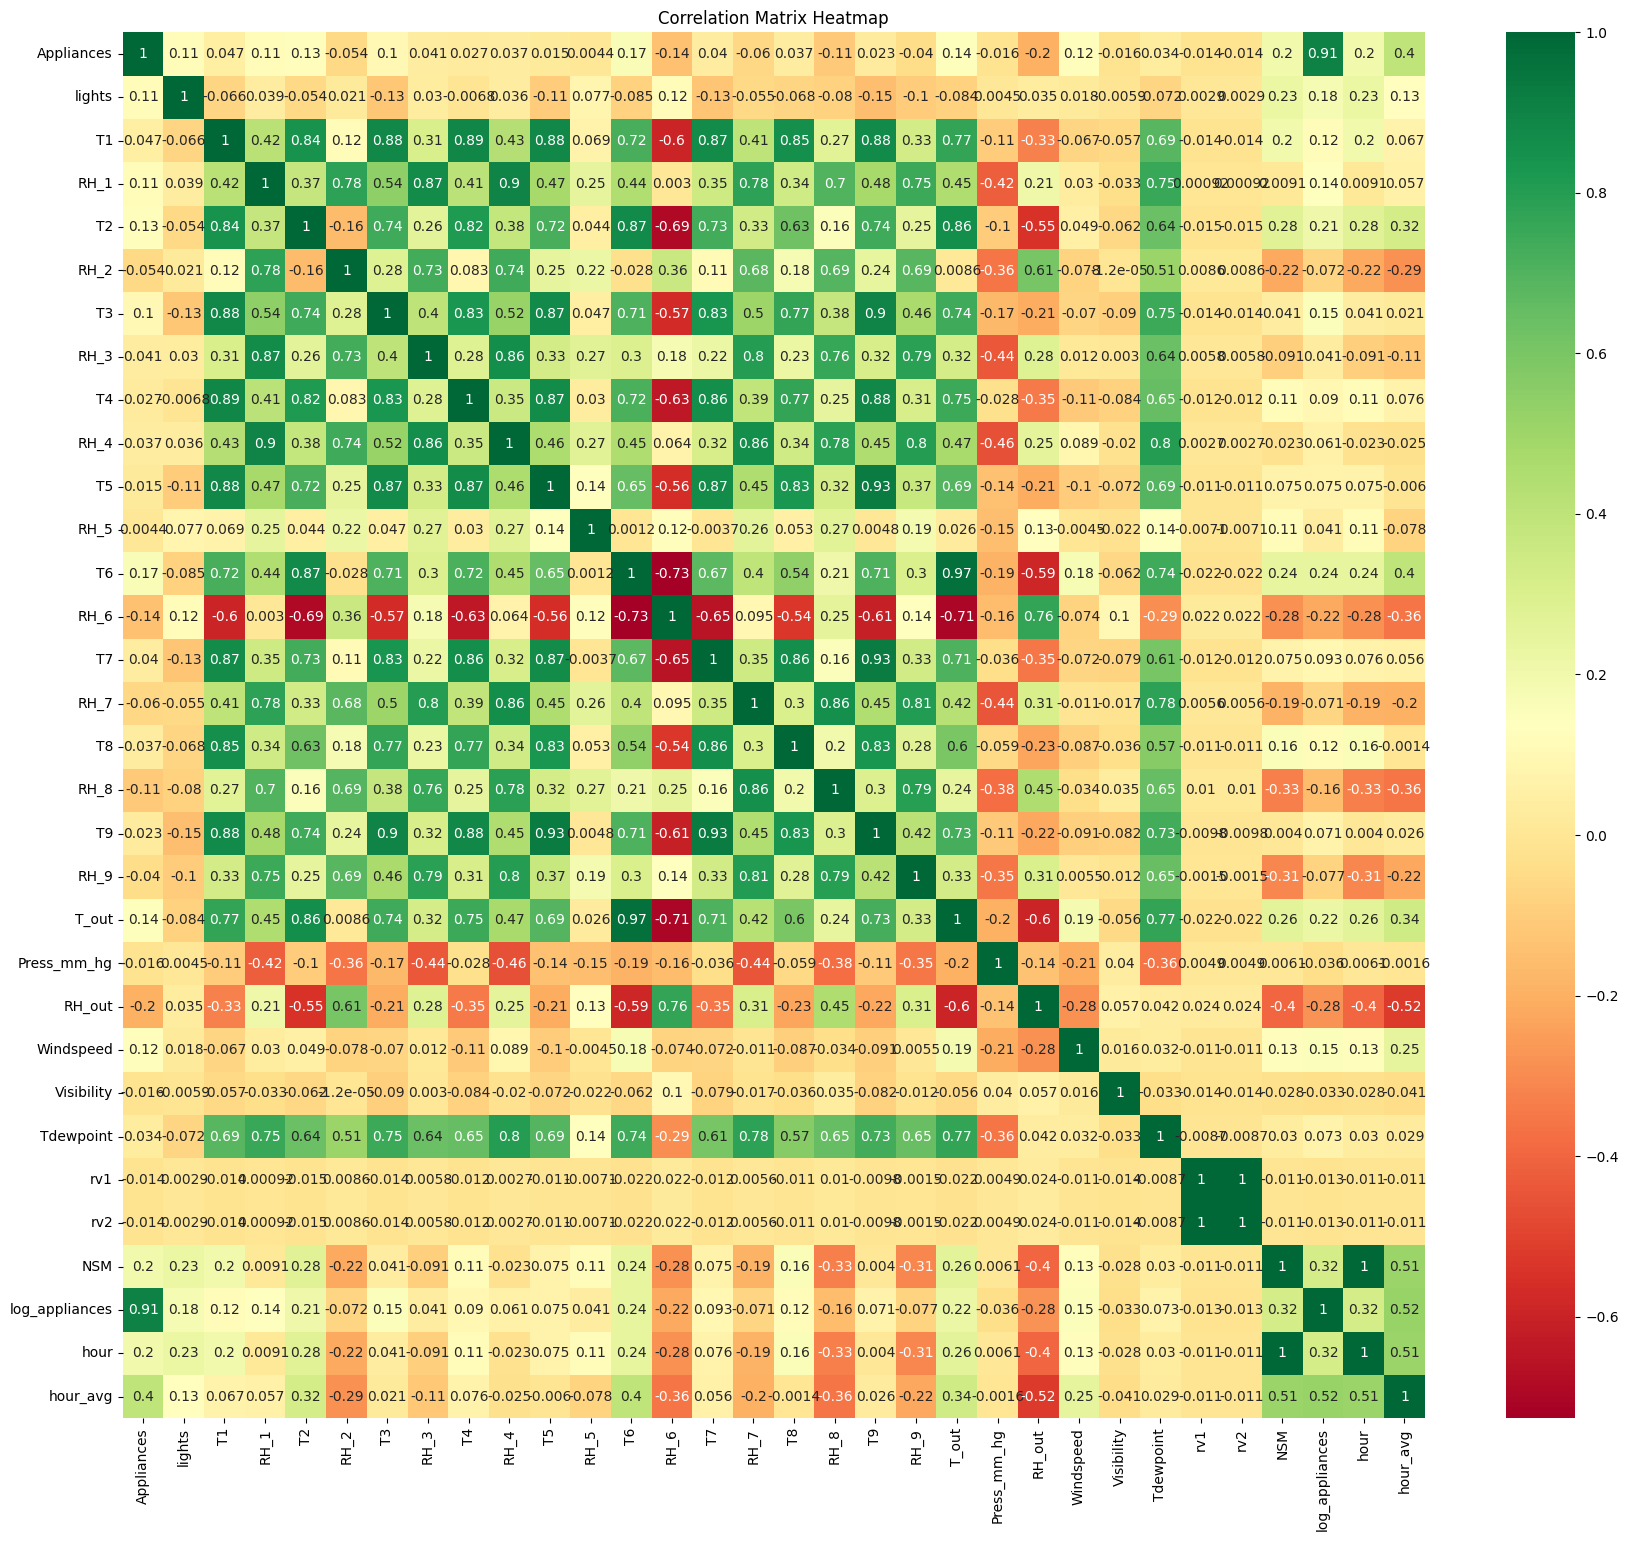

In [16]:
# chatGPT. Prompt: "plot the correlation heatmap"

# Correlation Heatmap visualization code
correlation_matrix = df.corr()
plt.figure(figsize=(21, 18))
sns.heatmap(correlation_matrix, annot=True, cmap="RdYlGn")
plt.title("Correlation Matrix Heatmap")
plt.show()

Insight from the heatmap: 
- All of the temperature indoor and outdoor are correlated -> keep the one that has the highest absolute correlation (***T_6***)
- All of the humidity indoor and outdoor are correlated -> keep the one that has the highest absolute correlation (***RH_6***)
- ***hour*** has the strongest correlation -> ***hour***
- the other climate related features such as ***Press_mm_hg, Windspeed, Visibility, Tdewpoint*** are kept
- ***light*** also has a significant correlation with log_appliances, but the rest is not. So we might conclude that there is no obvious ***linear correlation*** between the target and features, meaning that using Linear Methods might not be good choices.

### 2. Pre-process the data

In this section I have done:

- combining correlated features for temperature and humidity 
- keeping important features based on EDA above
- removing outliers from the dataset
- split the dataset into train, dev, test sets
- scale the dataset 

In [17]:
# chatGPT. Prompt: "create a new column of average indoor temperature and humidity and the difference between outside and inside building temperature and humidity"

df['avg_indoor_temp']=df[['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']].mean(axis=1)
df['temp_diff']=abs(df['avg_indoor_temp']-df['T_out'])

df['avg_indoor_hum']=df[['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']].mean(axis=1)
#create a column of difference between outside and inside building humidity
df['hum_diff']=abs(df['RH_out']-df['avg_indoor_hum'])

print(df.shape)

df.head()

(14941, 36)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,rv1,rv2,NSM,log_appliances,hour,hour_avg,avg_indoor_temp,temp_diff,avg_indoor_hum,hum_diff
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.79,21.39,40.59,19.2,41.00,...,48.320978,48.320978,0,3.912023,0,52.5,19.946250,17.046250,42.250417,55.749583
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.73,21.39,40.59,19.2,41.06,...,33.339359,33.339359,600,3.912023,0,52.5,19.937917,17.067917,42.311736,55.854931
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.79,21.39,40.53,19.2,41.09,...,8.168115,8.168115,1200,4.094345,0,52.5,19.901875,17.071875,42.391042,55.942292
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.79,21.39,40.59,19.2,41.09,...,16.197509,16.197509,1800,3.688879,0,52.5,19.887778,17.087778,42.455417,56.044583
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.79,21.39,40.59,19.1,41.09,...,12.559574,12.559574,2400,4.094345,0,52.5,19.860139,17.090139,42.518681,56.147986


As mentioned above, temperatures and humidities are strongly correlated, I averaged them and only kept the differences between indoor and outdoor in ***temp_diff & hum_diff***

In [18]:
numeric_data = df.select_dtypes(include=[np.number])
df_hour = numeric_data.resample('1H').mean()
df_hour.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,rv1,rv2,NSM,log_appliances,hour,hour_avg,avg_indoor_temp,temp_diff,avg_indoor_hum,hum_diff
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,53.333333,6.666667,21.685556,39.898889,19.915556,40.780000,21.390000,40.570000,19.166667,41.070000,...,27.370129,27.370129,1500.0,3.965993,0.0,52.500000,19.897141,17.080475,42.414873,56.001794
2016-02-14 01:00:00,53.333333,0.000000,21.410000,39.826667,19.622222,40.897778,21.478611,40.665417,19.033333,41.151111,...,22.984526,22.984526,5100.0,3.972797,1.0,51.891026,19.816944,17.116944,42.844554,56.155446
2016-02-14 02:00:00,55.000000,0.000000,21.197222,39.820556,19.392222,41.106667,21.463333,40.735000,18.948056,41.200000,...,27.117749,27.117749,8700.0,3.991685,2.0,50.608974,19.757593,17.057593,43.160602,55.422731
2016-02-14 03:00:00,46.666667,0.000000,21.009444,39.938889,19.159444,41.315278,21.397222,40.817778,18.884444,41.240000,...,37.644489,37.644489,12300.0,3.795718,3.0,49.791667,19.676690,16.976690,43.342569,54.240764
2016-02-14 04:00:00,58.333333,0.000000,20.812778,40.055000,19.005000,41.518333,21.390000,40.840417,18.801111,41.210000,...,24.764940,24.764940,15900.0,4.059262,4.0,51.250000,19.605613,16.988947,43.442656,52.724010


In [19]:
chosen_columns = ['hour', 'temp_diff', 'hum_diff', 'lights', 'T6', 'RH_6', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint', 'log_appliances', 'NSM']
df_hour = df_hour[chosen_columns]

In [20]:
#Spliting
train_dev_size = int(len(df_hour) * 0.75)

df_train_dev = df_hour.iloc[:train_dev_size] 
df_test = df_hour.iloc[train_dev_size:]

print(f"df_train_dev shape: {df_train_dev.shape}")
print(f"df_test shape: {df_test.shape}")

df_train_dev shape: (1868, 12)
df_test shape: (623, 12)


I did not follow the spliting ratio on MyUni because it resulted in a very small training dataset compare to the test set(1500 and 600 rows). I instead devided into roughly 90/10/10. Above is the first splitting, and then remove outliers and then split again later

In [21]:
#chatGPT. Prompt: "remove outliers by using IQR method"

# Handling Outliers
for ftr in list(df_train_dev.columns):
  print(f"Removing outliers of {ftr}")
  q_25= np.percentile(df[ftr], 25)
  q_75 = np.percentile(df[ftr], 75)
  iqr = q_75 - q_25
  cut_off = iqr * 1.5
  lower = q_25 - cut_off
  upper = q_75 + cut_off
  outliers = [x for x in df[ftr] if x < lower or x > upper]
  
  #removing outliers
  if len(outliers)!=0:

    def bin(row):
      if row[ftr]> upper:
        return upper
      if row[ftr] < lower:
        return lower
      else:
        return row[ftr]

    df_train_dev[ftr] =  df_train_dev.apply (lambda row: bin(row), axis=1)

Removing outliers of hour
Removing outliers of temp_diff
Removing outliers of hum_diff
Removing outliers of lights
Removing outliers of T6
Removing outliers of RH_6
Removing outliers of Press_mm_hg
Removing outliers of Windspeed
Removing outliers of Visibility
Removing outliers of Tdewpoint
Removing outliers of log_appliances
Removing outliers of NSM


/tmp/ipykernel_17383/2747780980.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_dev[ftr] =  df_train_dev.apply (lambda row: bin(row), axis=1)


Removing outliers followed these steps:
1. Calculate Q1, Q3
2. Calculate IQR
3. Calculate upper and lower bounds
4. Replace with upper or lower bound

In [22]:
splitting_index = int(len(df_train_dev)*0.8)

df_train = df_train_dev.iloc[:splitting_index]
df_dev = df_train_dev.iloc[splitting_index:]

X_train = df_train.drop(columns=['log_appliances'])
y_train = df_train['log_appliances']

X_dev = df_dev.drop(columns=['log_appliances'])
y_dev = df_dev['log_appliances']

X_test = df_test.drop(columns=['log_appliances'])
y_test = df_test['log_appliances']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_dev shape: {X_dev.shape}")
print(f"y_dev shape: {y_dev.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1494, 11)
y_train shape: (1494,)
X_dev shape: (374, 11)
y_dev shape: (374,)
X_test shape: (623, 11)
y_test shape: (623,)


In [23]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

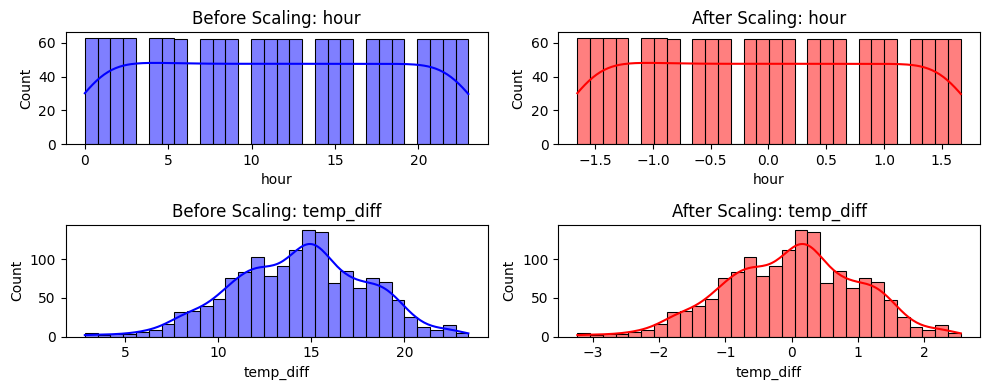

In [24]:
# chatGPT. Prompt: "plot before and after scaling histograms"

df_not_scaled = pd.DataFrame(X_train, columns=X_train.columns)
df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

fig, axes = plt.subplots(len(list(df_not_scaled.columns[:2])), 2, figsize=(10, 4))

for i, feature in enumerate(list(df_not_scaled.columns[:2])):
    #plotting the not scaled data
    sns.histplot(df_not_scaled[feature], bins=30, kde=True, ax=axes[i, 0], color="blue")
    axes[i, 0].set_title(f"Before Scaling: {feature}")
    
    # Plot the scaled data
    sns.histplot(df_scaled[feature], bins=30, kde=True, ax=axes[i, 1], color="red")
    axes[i, 1].set_title(f"After Scaling: {feature}")

plt.tight_layout()
plt.show()

After scaling, features have mean = 0 and std = 1, but still keep the shape

### 3. Implement, train and select prediction models

In this section, I have tried these models:
1. LinearRegression
2. GLM
3. RandomForestRegressor
4. LGBMRegressor
5. XGBRegressor
6. cbr

RandomForestRegressor yielded the best result!

#### Linear regression

In [44]:
lin_model = linear_model.LinearRegression()
lin_model.fit(X_train_scaled,y_train)

LinearRegression()

#### GLM

In [45]:
import statsmodels.api as sm

X_train_glm = sm.add_constant(X_train_scaled)
X_test_glm = sm.add_constant(X_test_scaled)

glm_model = sm.GLM(y_train, X_train_glm, family=sm.families.Gaussian())
glm_results = glm_model.fit()
print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         log_appliances   No. Observations:                 1494
Model:                            GLM   Df Residuals:                     1484
Model Family:                Gaussian   Df Model:                            9
Link Function:               Identity   Scale:                         0.21754
Method:                          IRLS   Log-Likelihood:                -975.42
Date:                Fri, 28 Feb 2025   Deviance:                       322.83
Time:                        15:43:19   Pearson chi2:                     323.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2630
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3012      0.012    356.451      0.0

#### Random Forest

In [46]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=1)            
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=1)

#### LGBMRegressor

In [47]:
model_lgb = lgb.LGBMRegressor(num_leaves=41, n_estimators=200)
model_lgb.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1802
[LightGBM] [Info] Number of data points in the train set: 1494, number of used features: 10
[LightGBM] [Info] Start training from score 4.301224


LGBMRegressor(n_estimators=200, num_leaves=41)

#### XGBRegressor

In [48]:
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### CatBoostRegressor

In [49]:
model_cbr = CatBoostRegressor(random_seed=242, verbose=0, early_stopping_rounds=10)
model_cbr.fit(X_train_scaled, y_train)

In [1]:
from sklearn.metrics import mean_squared_error

# Function to evaluate the models
def evaluate(model, test_features, test_labels):
    predictions = model.predict(test_features)
    errors = abs(predictions - test_labels)
    avg_error = np.mean(errors)
    mape = 100 * np.mean(errors / test_labels)
    r_score = 100 * r2_score(test_labels, predictions)
    accuracy = 100 - mape
    rmse = np.sqrt(mean_squared_error(test_labels, predictions))
    
    return (avg_error, mape, r_score, accuracy, rmse)

I chose MAPE and R2 score for a number of reasons. MAPE measures the average percentage between predicted and actual values, which is good for comparing across different scales. R2 score explains how well the model align with the variance in the data. I also calculated the accuracy by subtracting 100 by MAPE


In [51]:
# chatGPT. Prompt: "evaluate the GLM model"

from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_pred_glm = glm_results.predict(X_test_glm)

avg_error_glm = np.mean(abs(y_pred_glm - y_test))
mape_glm = mean_absolute_percentage_error(y_test, y_pred_glm)*100
r2_glm = r2_score(y_test, y_pred_glm)*100
accuracy_glm = 100 - mape_glm

result_glm = (avg_error_glm, mape_glm, r2_glm, accuracy_glm)
result_glm

(0.3692985944748753, 8.58219110048666, 4.89214445509022, 91.41780889951335)

/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


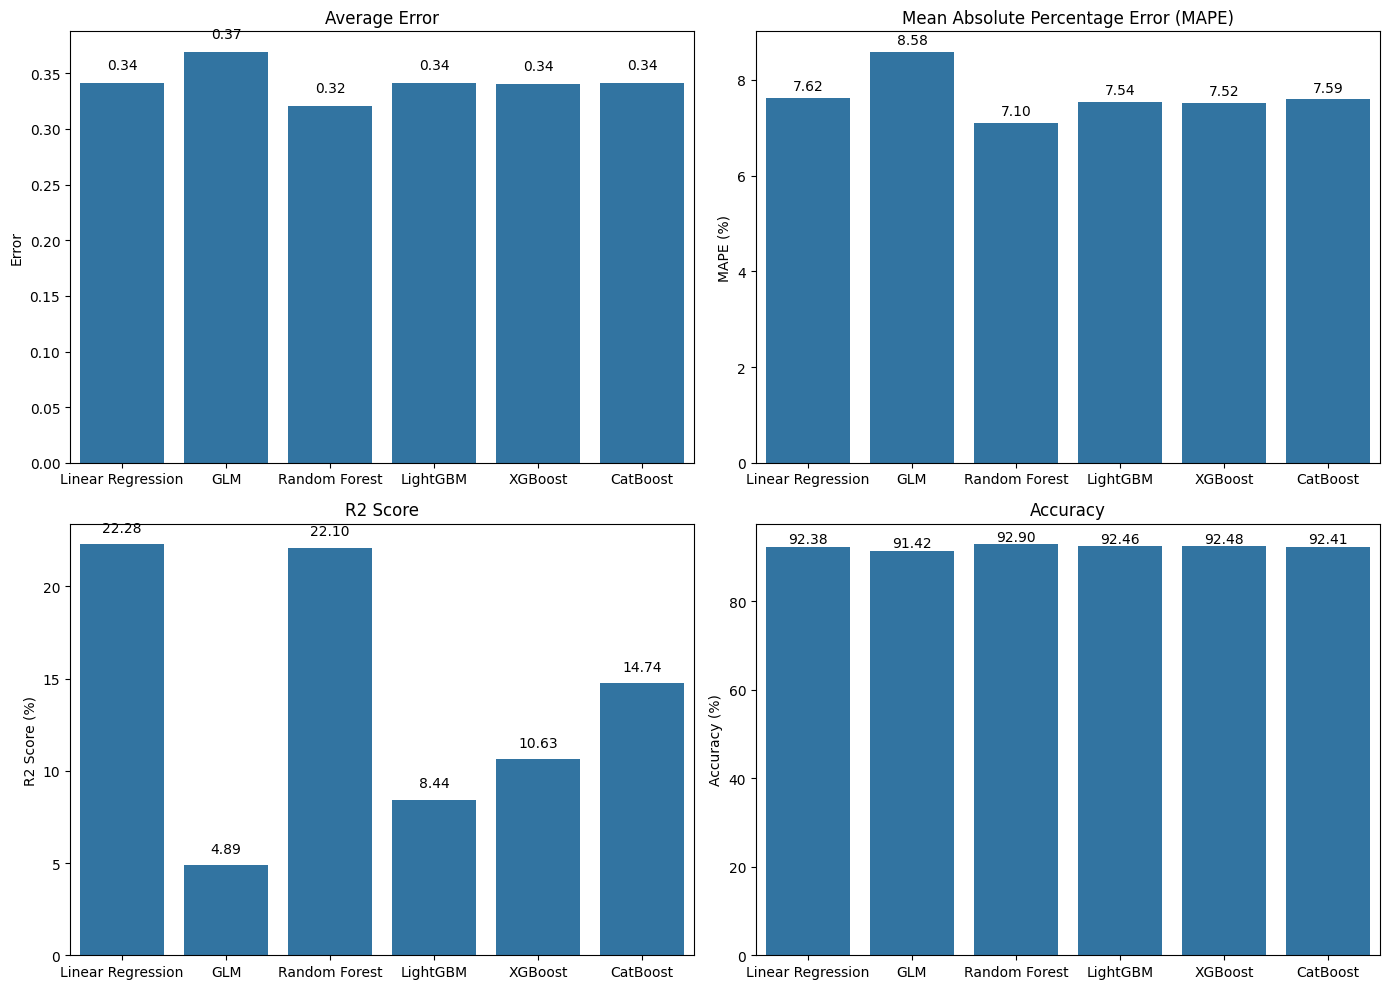

In [52]:
result_lin = evaluate(lin_model, X_dev_scaled, y_dev)
result_rf = evaluate(rf_model, X_dev_scaled, y_dev)
result_lgb = evaluate(model_lgb, X_dev_scaled, y_dev)
result_xgb = evaluate(model_xgb, X_dev_scaled, y_dev)
result_cbr = evaluate(model_cbr, X_dev_scaled, y_dev)

# Plotting the results
models = ['Linear Regression', 'GLM', 'Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']
results = [result_lin, result_glm, result_rf, result_lgb, result_xgb, result_cbr]

# Extracting metrics
avg_errors = [result[0] for result in results]
mapes = [result[1] for result in results]
r_scores = [result[2] for result in results]
accuracies = [result[3] for result in results]

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average Error
sns.barplot(x=models, y=avg_errors, ax=axes[0, 0])
axes[0, 0].set_title('Average Error')
axes[0, 0].set_ylabel('Error')
for i, v in enumerate(avg_errors):
    axes[0, 0].text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

# MAPE
sns.barplot(x=models, y=mapes, ax=axes[0, 1])
axes[0, 1].set_title('Mean Absolute Percentage Error (MAPE)')
axes[0, 1].set_ylabel('MAPE (%)')
for i, v in enumerate(mapes):
    axes[0, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom')

# R2 Score
sns.barplot(x=models, y=r_scores, ax=axes[1, 0])
axes[1, 0].set_title('R2 Score')
axes[1, 0].set_ylabel('R2 Score (%)')
for i, v in enumerate(r_scores):
    axes[1, 0].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom')

# Accuracy
sns.barplot(x=models, y=accuracies, ax=axes[1, 1])
axes[1, 1].set_title('Accuracy')
axes[1, 1].set_ylabel('Accuracy (%)')
for i, v in enumerate(accuracies):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

As can be seen from the result, especially R2, ***Random Forest Regressor, Linear Regression, XGBoost and CatBoost*** seem to be the best optio. Following is hyper parameter tuning using Grid Search for those models

In [53]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=1)            
rf_model.fit(X_train_scaled, y_train)

re = evaluate(rf_model, X_test, y_test)
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the GridSearchCV object
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

# Fit the grid search to the data
grid_search_rf.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"Best parameters found: {grid_search_rf.best_params_}")
print(f"Best score: {grid_search_rf.best_score_}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits


/home/james/MyFolder/code/GIT/mbd/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.4s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.5s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.6s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.0s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END bootstrap=True, max_depth=None, min_sam

In [54]:
rf_model = RandomForestRegressor(n_estimators=200,random_state=1, max_depth=10, min_samples_split=10, min_samples_leaf=4, bootstrap=True)            
rf_model.fit(X_train_scaled, y_train)

result_rf_train = evaluate(rf_model, X_train_scaled, y_train)
result_rf_dev = evaluate(rf_model, X_dev_scaled, y_dev)

print("Random Forest Model")
print(f"Dev Set: MAPE: {result_rf_dev[1]:.2f}%, R2 Score: {result_rf_dev[2]:.2f}%, Accuracy: {result_rf_dev[3]:.2f}%")
print(f"Train Set: MAPE: {result_rf_train[1]:.2f}%, R2 Score: {result_rf_train[2]:.2f}%, Accuracy: {result_rf_train[3]:.2f}%")

Random Forest Model
Dev Set: MAPE: 6.98%, R2 Score: 24.43%, Accuracy: 93.02%
Train Set: MAPE: 4.15%, R2 Score: 75.90%, Accuracy: 95.85%


In [55]:
# Define the parameter grid for XGBoost
model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
}

# Initialize the GridSearchCV object for XGBoost
grid_search_xgb = GridSearchCV(estimator=model_xgb, param_grid=param_grid_xgb, cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

# Fit the grid search to the data
grid_search_xgb.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"Best parameters found: {grid_search_xgb.best_params_}")
print(f"Best score: {grid_search_xgb.best_score_}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100; total time=   0.5s[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100; total time=   0.5s

[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200; total time=   0.6s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=100; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=100; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=100; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, min_c

In [56]:
model_xgb = xgb.XGBRegressor(n_estimators=300, learning_rate=0.01, random_state=42, max_depth=3, min_child_weight=3)
model_xgb.fit(X_train_scaled, y_train)

result_xgb_train = evaluate(model_xgb, X_train_scaled, y_train)
result_xgb_dev = evaluate(model_xgb, X_dev_scaled, y_dev)   

print("XGBoost Model")
print(f"Dev Set: MAPE: {result_xgb_dev[1]:.2f}%, R2 Score: {result_xgb_dev[2]:.2f}%, Accuracy: {result_xgb_dev[3]:.2f}%")
print(f"Train Set: MAPE: {result_xgb_train[1]:.2f}%, R2 Score: {result_xgb_train[2]:.2f}%, Accuracy: {result_xgb_train[3]:.2f}%")

XGBoost Model
Dev Set: MAPE: 6.95%, R2 Score: 29.12%, Accuracy: 93.05%
Train Set: MAPE: 6.13%, R2 Score: 48.52%, Accuracy: 93.87%


In [57]:
model_cbr = CatBoostRegressor(random_seed=242, verbose=0, early_stopping_rounds=10)
model_cbr.fit(X_train_scaled, y_train)
# Define the parameter grid for CatBoost
param_grid_cbr = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

# Initialize the GridSearchCV object for CatBoost
grid_search_cbr = GridSearchCV(estimator=model_cbr, param_grid=param_grid_cbr, cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

# Fit the grid search to the data
grid_search_cbr.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"Best parameters found: {grid_search_cbr.best_params_}")
print(f"Best score: {grid_search_cbr.best_score_}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.1; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.05; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.01; total time=   0.7s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.05; total time=   0.7s
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.01; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=1, learning_rate=0.05; total time=   1.2s
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.05; total time=   0.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.01; total time=   1.1s
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_r

In [58]:
model_cbr = CatBoostRegressor(depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.05)
model_cbr.fit(X_train_scaled, y_train)

result_xgb_train = evaluate(model_cbr, X_train_scaled, y_train)
result_xgb_dev = evaluate(model_cbr, X_dev_scaled, y_dev)   

print("CatBoostRegressor Model")
print(f"Dev Set: MAPE: {result_xgb_dev[1]:.2f}%, R2 Score: {result_xgb_dev[2]:.2f}%, Accuracy: {result_xgb_dev[3]:.2f}%")
print(f"Train Set: MAPE: {result_xgb_train[1]:.2f}%, R2 Score: {result_xgb_train[2]:.2f}%, Accuracy: {result_xgb_train[3]:.2f}%")

0:	learn: 0.5215027	total: 744us	remaining: 73.7ms
1:	learn: 0.5138689	total: 1.83ms	remaining: 89.7ms
2:	learn: 0.5055130	total: 2.38ms	remaining: 76.9ms
3:	learn: 0.4985031	total: 3.03ms	remaining: 72.8ms
4:	learn: 0.4919654	total: 3.68ms	remaining: 69.9ms
5:	learn: 0.4860446	total: 4.61ms	remaining: 72.3ms
6:	learn: 0.4798261	total: 5.22ms	remaining: 69.3ms
7:	learn: 0.4744268	total: 6.16ms	remaining: 70.8ms
8:	learn: 0.4700587	total: 7.46ms	remaining: 75.4ms
9:	learn: 0.4647374	total: 8.16ms	remaining: 73.5ms
10:	learn: 0.4603626	total: 8.71ms	remaining: 70.5ms
11:	learn: 0.4563876	total: 9.18ms	remaining: 67.3ms
12:	learn: 0.4528700	total: 9.76ms	remaining: 65.3ms
13:	learn: 0.4487458	total: 10.3ms	remaining: 63.6ms
14:	learn: 0.4455119	total: 10.9ms	remaining: 62ms
15:	learn: 0.4419242	total: 11.5ms	remaining: 60.3ms
16:	learn: 0.4387828	total: 12.1ms	remaining: 59ms
17:	learn: 0.4359493	total: 12.7ms	remaining: 57.8ms
18:	learn: 0.4338554	total: 13.4ms	remaining: 57ms
19:	learn:

As can be seen from after hyper parameter finetuning result, CatBoost gives us the best result where R2 score is 29.67 and MAPE is 6.81 on the Dev Set. And also R2 score on train set and dev set are closer, which means the model is less overfitting.

### 4. Test the final model and analyse results

In [27]:
df

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,rv1,rv2,NSM,log_appliances,hour,hour_avg,avg_indoor_temp,temp_diff,avg_indoor_hum,hum_diff
date,,,,,,,,,,,,,,,,,,,,,
2016-02-14 00:00:00,50,10,21.790000,39.900000,20.100000,40.790000,21.390000,40.590000,19.2,41.000000,...,48.320978,48.320978,0,3.912023,0,52.500000,19.946250,17.046250,42.250417,55.749583
2016-02-14 00:10:00,50,0,21.790000,39.900000,20.033333,40.730000,21.390000,40.590000,19.2,41.060000,...,33.339359,33.339359,600,3.912023,0,52.500000,19.937917,17.067917,42.311736,55.854931
2016-02-14 00:20:00,60,10,21.700000,39.933333,19.890000,40.790000,21.390000,40.530000,19.2,41.090000,...,8.168115,8.168115,1200,4.094345,0,52.500000,19.901875,17.071875,42.391042,55.942292
2016-02-14 00:30:00,40,0,21.633333,39.860000,19.890000,40.790000,21.390000,40.590000,19.2,41.090000,...,16.197509,16.197509,1800,3.688879,0,52.500000,19.887778,17.087778,42.455417,56.044583
2016-02-14 00:40:00,60,10,21.600000,39.900000,19.790000,40.790000,21.390000,40.590000,19.1,41.090000,...,12.559574,12.559574,2400,4.094345,0,52.500000,19.860139,17.090139,42.518681,56.147986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,45.590000,...,43.096812,43.096812,62400,4.605170,17,164.551282,24.869583,2.169583,46.137881,9.528786
2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,45.590000,...,49.282940,49.282940,63000,4.499810,17,164.551282,24.846810,2.246810,46.089286,9.910714
2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,45.730000,...,29.199117,29.199117,63600,5.598422,17,164.551282,24.818571,2.318571,46.237738,10.095595


In [28]:
chosen_columns = ['temp_diff', 'hum_diff', 'lights', 'T6', 'RH_6', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint', 'Appliances', 'NSM']
df = df[chosen_columns]
df

,hour,temp_diff,hum_diff,lights,T6,RH_6,Press_mm_hg,Windspeed,Visibility,Tdewpoint,Appliances,NSM
date,,,,,,,,,,,,
2016-02-14 00:00:00,0,17.046250,55.749583,10,3.530000,91.933333,732.90,2.000000,31.000000,2.6,50,0
2016-02-14 00:10:00,0,17.067917,55.854931,0,3.466667,92.156667,732.95,2.166667,28.500000,2.6,50,600
2016-02-14 00:20:00,0,17.071875,55.942292,10,3.400000,92.165000,733.00,2.333333,26.000000,2.6,60,1200
2016-02-14 00:30:00,0,17.087778,56.044583,0,3.400000,92.190000,733.05,2.500000,23.500000,2.6,40,1800
2016-02-14 00:40:00,0,17.090139,56.147986,10,3.400000,92.190000,733.10,2.666667,21.000000,2.6,60,2400
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:20:00,17,2.169583,9.528786,0,24.796667,1.000000,755.20,3.333333,23.666667,13.3,100,62400
2016-05-27 17:30:00,17,2.246810,9.910714,0,24.196667,1.000000,755.20,3.500000,24.500000,13.3,90,63000
2016-05-27 17:40:00,17,2.318571,10.095595,10,23.626667,1.000000,755.20,3.666667,25.333333,13.3,270,63600


Final Model: CatBoostRegressor
Average Error: 45.44
MAPE: 49.24
R2 Score: 10.78
Accuracy: 50.76
RMSE: 81.87


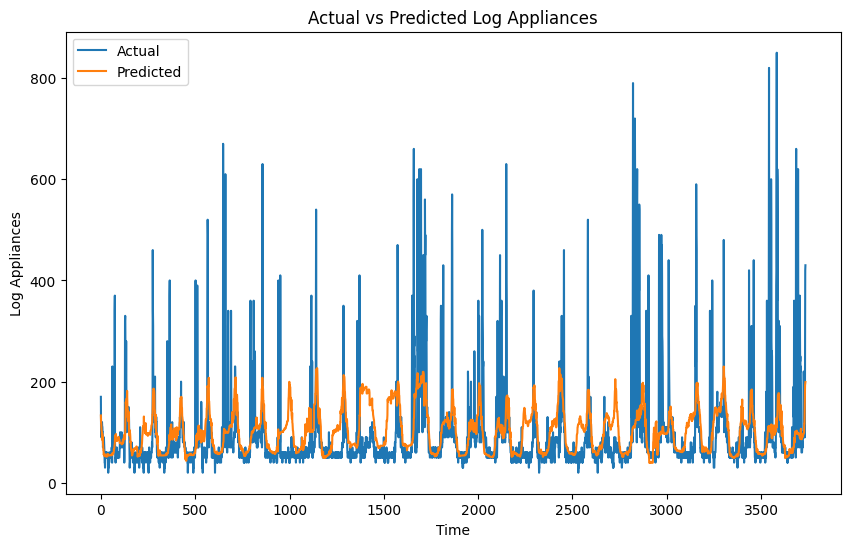

In [29]:
#Spliting
train_dev_size = int(len(df) * 0.75)

df_train = df.iloc[:train_dev_size] 
df_test = df.iloc[train_dev_size:]

X_train = df_train.drop(columns=['Appliances'])
y_train = df_train['Appliances']

X_test = df_test.drop(columns=['Appliances'])
y_test = df_test['Appliances']

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


final_model = CatBoostRegressor(depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.05, verbose=0)
final_model.fit(X_train_scaled, y_train)

# Predicting the test set
final_result = evaluate(final_model, X_test_scaled, y_test)
print(f"Final Model: CatBoostRegressor")
print(f"Average Error: {final_result[0]:.2f}")
print(f"MAPE: {final_result[1]:.2f}")
print(f"R2 Score: {final_result[2]:.2f}")
print(f"Accuracy: {final_result[3]:.2f}")
print(f"RMSE: {final_result[4]:.2f}")
# Plotting the final result
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(final_model.predict(X_test_scaled), label='Predicted')
plt.xlabel('Time')
plt.ylabel('Log Appliances')
plt.title('Actual vs Predicted Log Appliances')
plt.legend()
plt.show()

### 5. Reflection

#### 5.1. Objectives
The objective of this project is developing a machine learning model to predict the energy usage. In order to do that, I have done EDA, Data Processing, and modeling to achieve the best performance. Throughout those main tasks, some mistakes have been made, however, also have been evaluated and resolved. Because of the time limit, there are some ideas about how to further push the results.
#### 5.2. Development process
First, I have done EDA by making some asumption about the dataset. Data visualization techniques tools such as matplotlib and seaborn have been ultilized to extract most valuable insights about the whole dataset or specific features. Then, valuable features will be engineered, or even be introduced to the dataset. Some of the features are less important are aggregated, and some features do not show any correlatiton will be removed. During EDA, I have found that the dataset has a large amount of outliers, which has been handled. Ten features have been kept for scaling because this might help stablizing training process. Only then, the data is ready for training on 6 different models. After evaluating the result, three of the most promissing models were picked for further hyper parameters tuning. Finally, I tested the best model on the test set.
#### 5.3. Challenges and Mistakes
During the development process, I have made many challenges and mistakes. EDA is the hardest part in my experiance, because it involves a lot of evaluating technique to be able to get insights out of the plot. At first I did not know where to start, for example, which feature to plot out, which kind of plot to be used, etc. That led to some mistakes related to chosing the features. I dropped ***lights*** column out in the ***version01*** because I chose the wrong plot, I should have looked at the heatmap before deciding which features to be dropped. And I also split the data incorrectly at ***version4*** with different ratio from what on MyUni. One more mistake I have made is fit for scaling before spliting. 
#### 5.4. Evaluation and Adaptation
After carefully evaluating the result, I have changed the code and get the desired result without any bug. Data leaking is the most concerning part in my project, where I had to pay attention about when do feature engineering, scaling, and data splitting.
#### 5.5. Potential improvements
There are some potential improments such as using doing more EDA, trying different data preprocessing methods and trying more complex model (Neural network). And if I have more time, I might try to read more academic papers to understand the process more deeply.

### 6. References

* Candanedo, LM, Feldheim, V & Deramaix, D 2017, ‘Data driven prediction models of energy use of appliances in a low-energy house’, Energy and Buildings, vol. 140, pp. 81–97.

* Bharati, S, Podder, P & Mondal, MRH 2020, ‘Visualization and prediction of energy consumption in smart homes’, International Journal of Hybrid Intelligent Systems, pp. 1–17.

* Brownlee, J 2020, How to Scale Data With Outliers for Machine Learning, Machine Learning Mastery.

### 7. Appendix

I have used chatGPT in this project. Used prompts have been provided